# Exploratoty Data Analysis

Note: This notebook's sole purpose is to enlighten the reader on the behind the results obtained for the univariate and bivariate analysis. Interpratation of the results wil only be done in the paper.

# Non Stadard Library Instalations

In [31]:
#%pip install scipy

# Imports

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import t


# Data Prep

In order to prepare our data, we restrict our cleaned and processed data to only the selected variables.

In [39]:
Data = pd.read_csv("/Users/mathisvernier/Markovian-Embedding/data/processed/processed_FRED_MD.csv")
SELECTED = ["RPI", "DPCERA3M086SBEA", "UNRATE", "UEMPMEAN", "PERMIT",
            "ISRATIOx", "M1SL", "REALLN", "S&P PE ratio", "GS10",
            "EXSZUSx", "CUSR0000SAC", "CES2000000008"]

EDA_data = Data[SELECTED].copy()
EDA_data

,RPI,DPCERA3M086SBEA,UNRATE,UEMPMEAN,PERMIT,ISRATIOx,M1SL,REALLN,S&P PE ratio,GS10,EXSZUSx,CUSR0000SAC,CES2000000008
0,0.147391,-0.010510,-0.414864,0.489321,-0.626736,-0.506152,0.423179,-2.301239,-0.571287,0.111282,0.113248,-0.000742,0.891348
1,-0.235895,0.260628,-1.860909,-0.554210,-0.638974,1.103486,-0.191378,-0.409366,-1.168693,-0.840647,0.188616,-0.549289,0.432111
2,-0.101387,1.940698,2.959241,-0.162886,-1.073764,1.640032,-0.037657,0.133241,-0.475505,-0.877260,0.080223,1.096350,3.491949
3,0.191409,2.150293,-0.896879,-0.554210,-0.867291,-0.506151,-0.114710,-0.409159,0.071613,0.111282,0.104700,-0.002377,4.160806
4,-0.003937,-4.007209,-0.414864,-0.945534,-0.751179,1.640032,0.116450,-0.491496,-0.258956,0.257733,-0.047998,-0.547654,4.829662
...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,-0.217190,-0.699378,0.549166,-0.945534,0.328004,-0.488955,-0.170539,0.423031,-0.025570,-0.657584,-0.192485,-0.585632,-0.113296
782,0.752349,0.847387,0.549166,1.924177,0.389359,-0.488955,-0.248222,-0.457440,-1.540549,-0.620971,-0.818152,-0.997451,0.109194
783,0.908428,-0.250853,0.067151,0.489321,0.253794,0.030394,0.538468,0.137023,-1.508584,0.001444,-2.287020,0.791734,0.044766
784,-1.493021,-0.734069,0.067151,-1.858624,0.187477,0.549743,-0.491516,0.257698,1.481313,0.514021,-0.099743,-0.199291,-0.144300


In [ ]:
# Univariate Analysis

For this we will focus on the 13 selected variables individually.

# Bivariate Analysis

Now we will turn our attention to the bivariate relationships discussed in the paper:


However before we restrict ourselves to only these 4 pairs of variables we will look at some general characteristics of all the variable pairs. We first look at the correlation between all variables which results into the table ...  found in the appendix


In [41]:
results = []

#pair generation
for var1, var2 in combinations(SELECTED, 2):
    correlation = EDA_data[var1].corr(EDA_data[var2])
    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Correlation": correlation
    })

correlation_table = pd.DataFrame(results)
correlation_table["Correlation"] = (
    correlation_table["Correlation"].round(3)
)

print(correlation_table)



     Variable 1       Variable 2  Correlation
0           RPI  DPCERA3M086SBEA        0.129
1           RPI           UNRATE       -0.006
2           RPI         UEMPMEAN       -0.035
3           RPI           PERMIT        0.059
4           RPI         ISRATIOx       -0.021
..          ...              ...          ...
73         GS10      CUSR0000SAC        0.055
74         GS10    CES2000000008        0.008
75      EXSZUSx      CUSR0000SAC       -0.057
76      EXSZUSx    CES2000000008        0.000
77  CUSR0000SAC    CES2000000008        0.012

[78 rows x 3 columns]


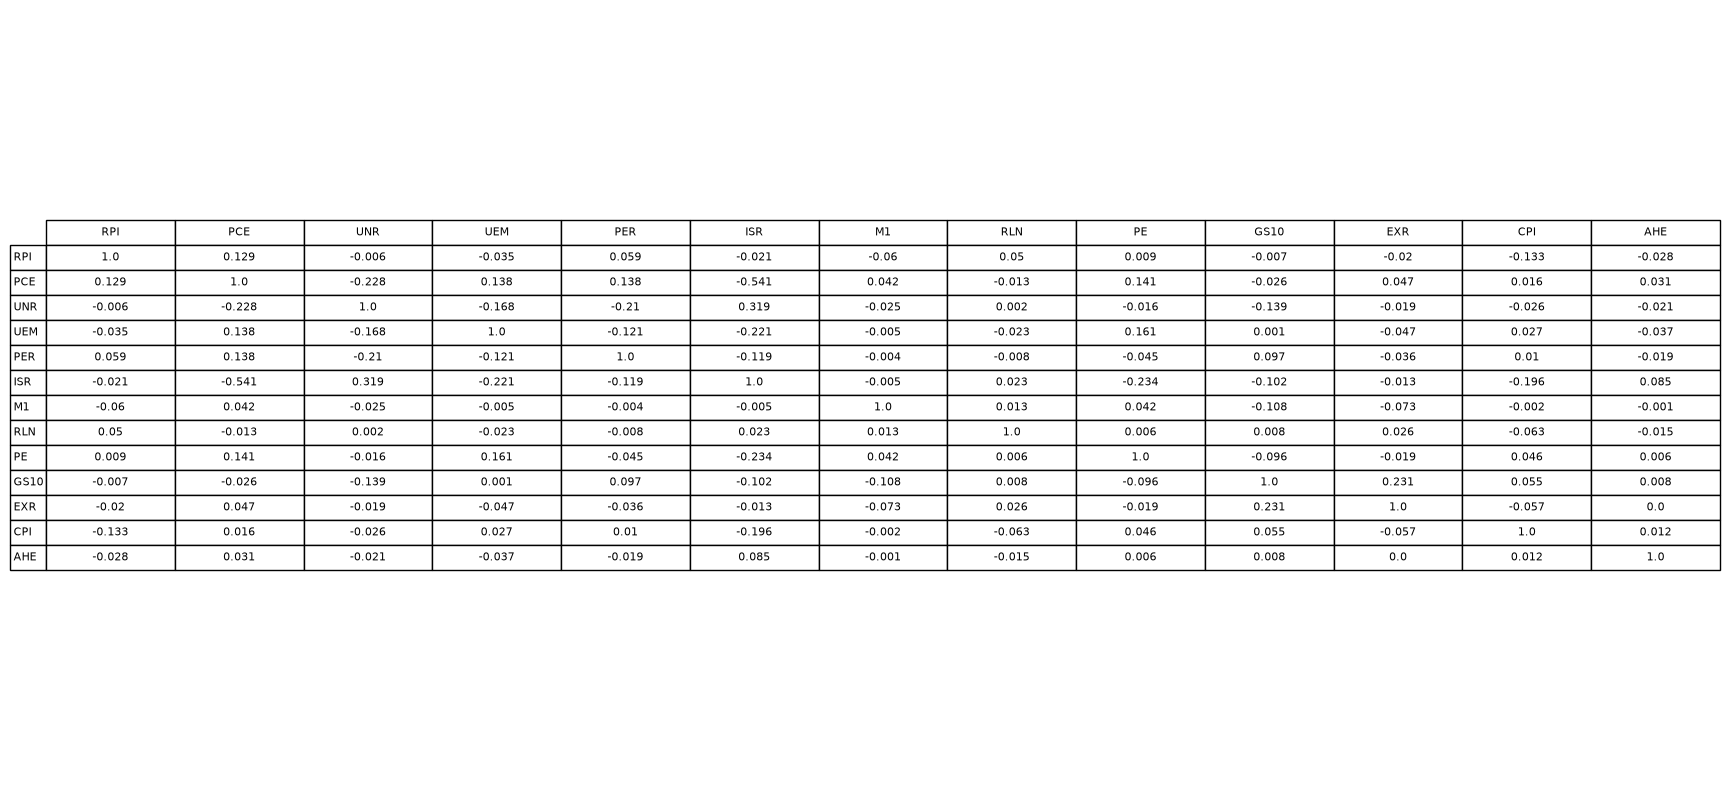

In [43]:
#same thing but now in a table and with smaller names so that it fits

short_names = {
    "RPI": "RPI",
    "DPCERA3M086SBEA": "PCE",
    "UNRATE": "UNR",
    "UEMPMEAN": "UEM",
    "PERMIT": "PER",
    "ISRATIOx": "ISR",
    "M1SL": "M1",
    "REALLN": "RLN",
    "S&P PE ratio": "PE",
    "GS10": "GS10",
    "EXSZUSx": "EXR",
    "CUSR0000SAC": "CPI",
    "CES2000000008": "AHE"
}

EDA_data_2 = Data[SELECTED].copy()
EDA_data_2 = EDA_data_2.rename(columns=short_names)
correlation_matrix = EDA_data_2.corr().round(3)

fig, ax = plt.subplots(figsize=(18, 10))
ax.axis("off")


table = ax.table(
    cellText=correlation_matrix.round(3).values,
    rowLabels=correlation_matrix.index,
    colLabels=correlation_matrix.columns,
    cellLoc="center",
    loc="center"
)


table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)




Now that we have a general overview of the correlation between all variable pairs, we will now focus on the pair only. We will again first generate a table with their corralations as well as testing them for statistical significance using the t-stat as wella s the p value. We will than move to lagged correlation and finally cointegration

In [44]:
#same code as above but restricted to the 4 pairs
#relationships
relationships = [
    ("UNRATE", "CES2000000008"),
    ("PERMIT", "ISRATIOx"),
    ("RPI", "DPCERA3M086SBEA"),
    ("S&P PE ratio", "GS10")
]

results = []


for var1, var2 in relationships:

    correlation = Data[var1].corr(Data[var2])

    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Correlation": correlation
    })

correlation_table = pd.DataFrame(results)

correlation_table["Correlation"] = (
    correlation_table["Correlation"].round(3)
)


print(correlation_table.to_string(index=False))

  Variable 1      Variable 2  Correlation
      UNRATE   CES2000000008       -0.021
      PERMIT        ISRATIOx       -0.119
         RPI DPCERA3M086SBEA        0.129
S&P PE ratio            GS10       -0.096


In [ ]:
results = []

for var1, var2 in relationships:

    pair_data = Data[[var1, var2]]
    n = len(pair_data)

    #correlation
    r = pair_data[var1].corr(
        pair_data[var2],
        method="pearson"
    )

    #t-stat
    t_statistic = r * (
        (n - 2) / (1 - r**2)
    )**0.5

    degrees_freedom = n - 2

    #two-sided p value
    p_value = 2 * t.sf(
        abs(t_statistic),
        degrees_freedom
    )

    #significance at the 5% level
    if p_value < 0.05:
        result = "Significant"
    else:
        result = "Not significant"

    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "n": n,
        "Correlation r": round(r, 3),
        "t-statistic": round(t_statistic, 3),
        "p-value": round(p_value, 4),
        "Result": result
    })

correlation_test_table = pd.DataFrame(results)

print(
    correlation_test_table.to_string(
        index=False
    )
)

  Variable 1      Variable 2   n  Pearson r  t-statistic  p-value          Result
      UNRATE   CES2000000008 786     -0.021       -0.576   0.5645 Not significant
      PERMIT        ISRATIOx 786     -0.119       -3.358   0.0008     Significant
         RPI DPCERA3M086SBEA 786      0.129        3.639   0.0003     Significant
S&P PE ratio            GS10 786     -0.096       -2.695   0.0072     Significant
